# Mutual Fund Performance Analytics & Scorecard

This notebook contains the end-to-end quantitative financial analysis of 40 mutual fund schemes over a 4.4-year period (January 2022 to May 2026).

## Key Tasks Performed:
1. **Daily Returns Computation & Distribution Validation**
2. **CAGR Calculations (1-Year, 3-Year, and 4.4-Year Full History)**
3. **Sharpe & Sortino Ratios (Risk-Adjusted Performance)**
4. **OLS Regression against Nifty 100 (Alpha & Beta)**
5. **Maximum Drawdown and worst drawdown periods**
6. **Composite Fund Scorecard (0-100 Score & Rankings)**
7. **Benchmark Comparison Chart & Tracking Error Calculations**

---

In [1]:
# Imports
import sqlite3
import pandas as pd
import numpy as np
import scipy.stats
import matplotlib.pyplot as plt
import seaborn as sns

# Plotting style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["figure.dpi"] = 100

print("Libraries imported successfully.")

Libraries imported successfully.


## 1. Load and Align Data

We connect to the SQLite database and retrieve the daily NAV history for all 40 funds. To prevent weekend forward-fillings (NAV constant over Saturday/Sunday) from artificially lowering our volatility measurements (which would inflate Sharpe and Sortino ratios), we inner-join the NAV history with the Nifty 100 benchmark index trading days (1,150 days total).

In [2]:
# Database and raw data file paths
db_path = '../data/db/bluestock_mf.db'
bench_csv = '../data/raw/10_benchmark_indices.csv'

# Connect to DB
conn = sqlite3.connect(db_path)

# Load dim_fund
df_funds = pd.read_sql_query("""
    SELECT amfi_code, scheme_name, fund_house, category, sub_category, plan, expense_ratio_pct 
    FROM dim_fund
""", conn)

# Load fact_nav
df_nav = pd.read_sql_query("""
    SELECT amfi_code, date, nav 
    FROM fact_nav 
    ORDER BY amfi_code, date
""", conn)
df_nav["date"] = pd.to_datetime(df_nav["date"])

# Load benchmark indices
df_bench = pd.read_csv(bench_csv)
df_bench["date"] = pd.to_datetime(df_bench["date"])

# Pivot benchmark indices to get Nifty 50 and Nifty 100 close prices in columns
df_n50 = df_bench[df_bench["index_name"] == "NIFTY50"].rename(columns={"close_value": "nifty50_close"})
df_n100 = df_bench[df_bench["index_name"] == "NIFTY100"].rename(columns={"close_value": "nifty100_close"})
df_benchmarks = pd.merge(df_n50[["date", "nifty50_close"]], df_n100[["date", "nifty100_close"]], on="date", how="inner")

# Merge NAV history with benchmark trading days and dim_fund metadata
df_aligned = pd.merge(df_nav, df_benchmarks, on="date", how="inner")
df_aligned = pd.merge(df_aligned, df_funds, on="amfi_code", how="inner")
df_aligned.sort_values(["amfi_code", "date"], inplace=True)

print(f"Loaded {len(df_funds)} schemes.")
print(f"Aligned NAV history rows: {len(df_aligned)} ({len(df_aligned)/40:.1f} trading days per scheme).")
conn.close()

Loaded 40 schemes.
Aligned NAV history rows: 46000 (1150.0 trading days per scheme).


## 2. Compute Daily Returns & Validate Distribution

We calculate daily returns for all funds: $R_{t} = \frac{NAV_t}{NAV_{t-1}} - 1$.
We then validate that the return distributions are mathematically reasonable (centered near 0 with realistic standard deviations) and plot a visual check.

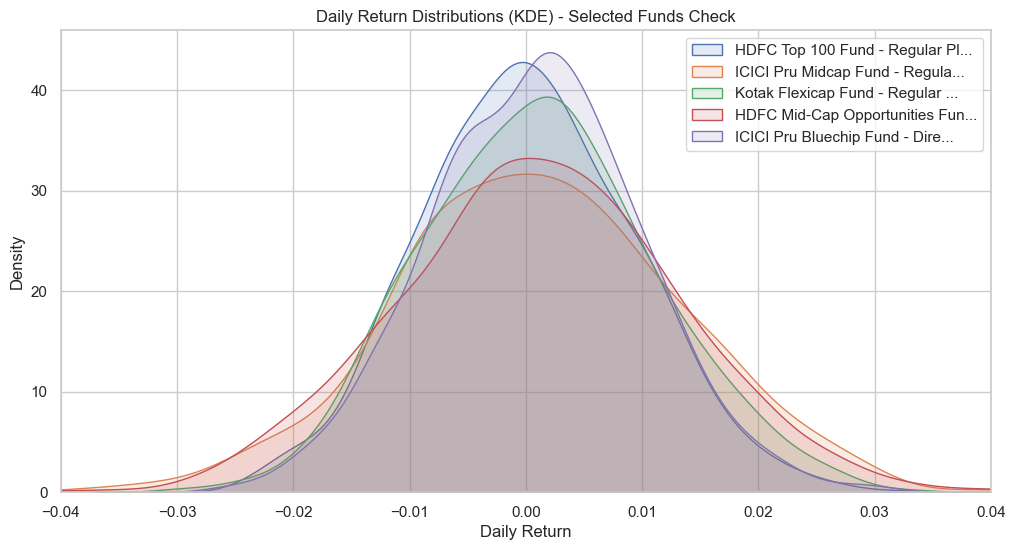

Skewness & Kurtosis Checks:
100016 Skew: 0.121, Kurtosis: -0.098
120505 Skew: 0.001, Kurtosis: -0.003
120843 Skew: 0.120, Kurtosis: -0.120
100033 Skew: -0.009, Kurtosis: 0.083
120504 Skew: 0.066, Kurtosis: 0.029


In [3]:
# Calculate daily returns
df_aligned["fund_return"] = df_aligned.groupby("amfi_code")["nav"].pct_change()
df_aligned["nifty50_return"] = df_aligned.groupby("amfi_code")["nifty50_close"].pct_change()
df_aligned["nifty100_return"] = df_aligned.groupby("amfi_code")["nifty100_close"].pct_change()

# Drop the first row of returns (which will be NaN)
df_ret_clean = df_aligned.dropna(subset=["fund_return"]).copy()

# Plot return distribution for a subset of major funds as validation
sample_amfis = [100016, 120505, 120843, 100033, 120504]
df_sample = df_ret_clean[df_ret_clean["amfi_code"].isin(sample_amfis)].copy()

plt.figure(figsize=(12, 6))
for amfi in sample_amfis:
    fund_data = df_sample[df_sample["amfi_code"] == amfi]
    sns.kdeplot(fund_data["fund_return"], label=fund_data["scheme_name"].iloc[0][:30] + "...", fill=True, alpha=0.15)

plt.title("Daily Return Distributions (KDE) - Selected Funds Check")
plt.xlabel("Daily Return")
plt.ylabel("Density")
plt.xlim(-0.04, 0.04)
plt.legend()
plt.show()

# Print distribution summary metrics for check
print("Skewness & Kurtosis Checks:")
for amfi in sample_amfis:
    fund_ret = df_ret_clean[df_ret_clean["amfi_code"] == amfi]["fund_return"]
    print(f"{amfi} Skew: {scipy.stats.skew(fund_ret):.3f}, Kurtosis: {scipy.stats.kurtosis(fund_ret):.3f}")

## 3. Compute CAGR for 1-Year, 3-Year, and 5-Year (Proxy)

Compounded Annual Growth Rate (CAGR) is computed as:
$$CAGR = \left(\frac{NAV_{end}}{NAV_{start}}\right)^{\frac{1}{n}} - 1$$

Note: Since our dataset spans **4.40 years** (from '2022-01-03' to '2026-05-29'), the 5-Year CAGR column calculates the CAGR over this full available 4.40-year period ($n \approx 4.402$ years) and is a proxy for the 5-year return.

In [4]:
# List to collect analytical results
results = []
Rf = 0.065
Rf_daily = Rf / 252

for amfi in df_funds["amfi_code"]:
    df_f = df_ret_clean[df_ret_clean["amfi_code"] == amfi].copy()
    fund_info = df_funds[df_funds["amfi_code"] == amfi].iloc[0]
    
    fund_ret_series = df_f["fund_return"]
    mean_daily = fund_ret_series.mean()
    std_daily = fund_ret_series.std()
    
    # NAV Values
    nav_end = df_f["nav"].iloc[-1]
    
    # 1yr start: closest to 2025-05-29
    idx_1yr = (df_f["date"] - pd.Timestamp("2025-05-29")).abs().idxmin()
    nav_1yr = df_f.loc[idx_1yr, "nav"]
    cagr_1yr = (nav_end / nav_1yr) - 1
    
    # 3yr start: closest to 2023-05-29
    idx_3yr = (df_f["date"] - pd.Timestamp("2023-05-29")).abs().idxmin()
    nav_3yr = df_f.loc[idx_3yr, "nav"]
    cagr_3yr = (nav_end / nav_3yr) ** (1/3.0) - 1
    
    # 5yr (max available) start: first date (2022-01-03)
    nav_start = df_f["nav"].iloc[0]
    n_years = (df_f["date"].iloc[-1] - df_f["date"].iloc[0]).days / 365.25
    cagr_5yr = (nav_end / nav_start) ** (1/n_years) - 1
    
    # Sharpe Ratio
    sharpe = (mean_daily - Rf_daily) / std_daily * np.sqrt(252)
    
    # Sortino Ratio
    neg_returns = fund_ret_series[fund_ret_series < 0]
    downside_std_daily = neg_returns.std()
    sortino = (mean_daily - Rf_daily) / downside_std_daily * np.sqrt(252)
    
    # Alpha & Beta vs Nifty 100
    slope, intercept, r_val, p_val, std_err = scipy.stats.linregress(df_f["nifty100_return"], fund_ret_series)
    beta = slope
    alpha = intercept * 252
    r_squared = r_val ** 2
    
    # Maximum Drawdown and Date Range
    nav_series = df_f["nav"].values
    running_max = np.maximum.accumulate(nav_series)
    drawdowns = nav_series / running_max - 1
    max_dd = drawdowns.min()
    
    trough_idx = drawdowns.argmin()
    peak_idx = nav_series[:trough_idx+1].argmax()
    
    peak_date = df_f["date"].iloc[peak_idx].strftime("%Y-%m-%d")
    trough_date = df_f["date"].iloc[trough_idx].strftime("%Y-%m-%d")
    dd_range = f"{peak_date} to {trough_date}"
    
    results.append({
        "amfi_code": amfi,
        "scheme_name": fund_info["scheme_name"],
        "fund_house": fund_info["fund_house"],
        "category": fund_info["category"],
        "sub_category": fund_info["sub_category"],
        "plan": fund_info["plan"],
        "expense_ratio_pct": fund_info["expense_ratio_pct"],
        "cagr_1yr": cagr_1yr,
        "cagr_3yr": cagr_3yr,
        "cagr_5yr": cagr_5yr,
        "sharpe_ratio": sharpe,
        "sortino_ratio": sortino,
        "alpha": alpha,
        "beta": beta,
        "r_squared": r_squared,
        "p_value": p_val,
        "max_drawdown": max_dd,
        "drawdown_range": dd_range
    })

df_metrics = pd.DataFrame(results)
print("Metrics calculated for all 40 schemes.")

Metrics calculated for all 40 schemes.


### CAGR Comparison Table across all Funds (Sorted by 3-Year CAGR)

In [5]:
cagr_table = df_metrics[["amfi_code", "scheme_name", "category", "cagr_1yr", "cagr_3yr", "cagr_5yr"]].copy()
cagr_table["cagr_1yr"] = cagr_table["cagr_1yr"] * 100
cagr_table["cagr_3yr"] = cagr_table["cagr_3yr"] * 100
cagr_table["cagr_5yr"] = cagr_table["cagr_5yr"] * 100

cagr_table.rename(columns={
    "cagr_1yr": "1-Year CAGR (%)",
    "cagr_3yr": "3-Year CAGR (%)",
    "cagr_5yr": "5-Year CAGR (Proxy %)"
}, inplace=True)

cagr_table.sort_values("3-Year CAGR (%)", ascending=False, inplace=True)
cagr_table.reset_index(drop=True, inplace=True)
cagr_table

,amfi_code,scheme_name,category,1-Year CAGR (%),3-Year CAGR (%),5-Year CAGR (Proxy %)
0,119094,Axis Midcap Fund - Regular - Growth,Equity,22.261065,35.111802,28.339403
1,148567,Mirae Asset Large Cap Fund - Regular - Growth,Equity,20.360678,34.000916,30.427322
2,120504,ICICI Pru Bluechip Fund - Direct - Growth,Equity,13.064279,32.487429,23.635060
3,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,Equity,53.232396,32.442459,30.542236
4,120505,ICICI Pru Midcap Fund - Regular - Growth,Equity,29.604659,31.777537,33.459588
5,119551,SBI Bluechip Fund - Regular Plan - Growth,Equity,60.437341,30.456524,25.842778
6,120843,Kotak Flexicap Fund - Regular - Growth,Equity,26.657082,29.582770,30.394617
7,148569,Mirae Asset Tax Saver Fund - Regular - Growth,Equity,39.751761,29.178902,31.722136
8,101206,ABSL Frontline Equity Fund - Regular - Growth,Equity,47.924120,28.967695,23.522244
9,149324,DSP Small Cap Fund - Regular - Growth,Equity,65.138719,27.000427,32.628442


## 4. Sharpe & Sortino Ratios Ranking

We calculate Sharpe Ratio and Sortino Ratio for each fund and rank them.
Sortino Ratio uses the downside standard deviation (standard deviation of daily return on negative return days only).

In [6]:
risk_table = df_metrics[["amfi_code", "scheme_name", "category", "sharpe_ratio", "sortino_ratio"]].copy()
risk_table["sharpe_rank"] = risk_table["sharpe_ratio"].rank(ascending=False, method='min')
risk_table["sortino_rank"] = risk_table["sortino_ratio"].rank(ascending=False, method='min')

risk_table.sort_values("sharpe_ratio", ascending=False, inplace=True)
risk_table.reset_index(drop=True, inplace=True)
risk_table

,amfi_code,scheme_name,category,sharpe_ratio,sortino_ratio,sharpe_rank,sortino_rank
0,148567,Mirae Asset Large Cap Fund - Regular - Growth,Equity,1.448291,2.385644,1.0,1.0
1,120843,Kotak Flexicap Fund - Regular - Growth,Equity,1.306744,2.364320,2.0,2.0
2,148569,Mirae Asset Tax Saver Fund - Regular - Growth,Equity,1.234930,2.146914,3.0,3.0
3,119551,SBI Bluechip Fund - Regular Plan - Growth,Equity,1.208267,2.140267,4.0,4.0
4,120505,ICICI Pru Midcap Fund - Regular - Growth,Equity,1.180101,2.029353,5.0,5.0
5,149323,DSP Midcap Fund - Regular - Growth,Equity,1.132122,1.875101,6.0,6.0
6,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,Equity,1.093699,1.829134,7.0,8.0
7,118632,Nippon India Large Cap Fund - Regular - Growth,Equity,1.081659,1.850133,8.0,7.0
8,101206,ABSL Frontline Equity Fund - Regular - Growth,Equity,1.027213,1.799563,9.0,10.0
9,120504,ICICI Pru Bluechip Fund - Direct - Growth,Equity,1.026524,1.805294,10.0,9.0


## 5. Alpha & Beta Regression (OLS Regression vs Nifty 100)

We regress daily fund returns on daily Nifty 100 returns using ordinary least squares (OLS) regression.
- **Beta** is the slope of the regression, measuring sensitivity to index moves.
- **Annualized Alpha** is the intercept multiplied by 252, representing the fund's risk-adjusted value-add.

In [7]:
alpha_beta_table = df_metrics[["amfi_code", "scheme_name", "alpha", "beta", "r_squared", "p_value"]].copy()
alpha_beta_table.sort_values("alpha", ascending=False, inplace=True)
alpha_beta_table.reset_index(drop=True, inplace=True)
alpha_beta_table

,amfi_code,scheme_name,alpha,beta,r_squared,p_value
0,119598,SBI Small Cap Fund - Regular Plan - Growth,0.303370,-0.023196,1.414258e-04,0.687179
1,149324,DSP Small Cap Fund - Regular - Growth,0.300579,0.011455,3.532991e-05,0.840494
2,120505,ICICI Pru Midcap Fund - Regular - Growth,0.292636,0.000549,1.345534e-07,0.990090
3,148569,Mirae Asset Tax Saver Fund - Regular - Growth,0.282704,0.018134,1.748889e-04,0.654295
4,120843,Kotak Flexicap Fund - Regular - Growth,0.273305,-0.022830,3.430543e-04,0.530528
5,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.271954,0.005104,1.206652e-05,0.906369
6,148567,Mirae Asset Large Cap Fund - Regular - Growth,0.269838,0.023684,4.625437e-04,0.466427
7,149323,DSP Midcap Fund - Regular - Growth,0.265986,-0.002523,3.357978e-06,0.950525
8,119094,Axis Midcap Fund - Regular - Growth,0.260767,-0.066265,1.936879e-03,0.135988
9,119551,SBI Bluechip Fund - Regular Plan - Growth,0.232010,-0.031751,8.869789e-04,0.313143


## 6. Maximum Drawdown & Date Ranges

Maximum Drawdown is calculated as $\min\left(\frac{NAV}{Running Max} - 1\right)$.

In [8]:
drawdown_table = df_metrics[["amfi_code", "scheme_name", "max_drawdown", "drawdown_range"]].copy()
drawdown_table["max_drawdown_pct"] = drawdown_table["max_drawdown"] * 100
drawdown_table = drawdown_table[["amfi_code", "scheme_name", "max_drawdown_pct", "drawdown_range"]]
drawdown_table.sort_values("max_drawdown_pct", ascending=True, inplace=True)
drawdown_table.reset_index(drop=True, inplace=True)
drawdown_table

,amfi_code,scheme_name,max_drawdown_pct,drawdown_range
0,119599,SBI Small Cap Fund - Direct Plan - Growth,-52.574221,2023-01-17 to 2025-10-28
1,119095,Axis Small Cap Fund - Regular - Growth,-51.677754,2025-05-22 to 2026-05-11
2,101207,ABSL Small Cap Fund - Regular - Growth,-35.446916,2024-11-21 to 2026-05-11
3,149324,DSP Small Cap Fund - Regular - Growth,-31.171900,2024-05-03 to 2025-01-03
4,119598,SBI Small Cap Fund - Regular Plan - Growth,-28.706006,2024-08-28 to 2025-05-14
5,102886,UTI Mid Cap Fund - Regular - Growth,-28.001124,2025-01-07 to 2026-04-27
6,100016,HDFC Top 100 Fund - Regular Plan - Growth,-24.734441,2022-03-30 to 2022-09-15
7,120842,Kotak Emerging Equity Fund - Regular - Growth,-24.003511,2023-11-09 to 2024-10-17
8,118634,Nippon India Small Cap Fund - Regular - Growth,-23.344886,2025-04-09 to 2026-02-20
9,119093,Axis Bluechip Fund - Direct - Growth,-21.751396,2022-02-24 to 2023-05-22


## 7. Fund Scorecard (0-100)

We build a composite scorecard based on the following weights:
- **30%** × 3yr Return Rank (ascending)
- **25%** × Sharpe Rank (ascending)
- **20%** × Alpha Rank (ascending)
- **15%** × Expense Ratio Rank (descending, lower expense is better)
- **10%** × Max DD Rank (descending/ascending on negative numbers, smaller drawdown magnitude is better)

Ranks are normalized to a 0-100 scale: $Score = \frac{Rank - 1}{N - 1} \times 100$, where $N = 40$ funds.

In [9]:
N = len(df_metrics)

# Compute Ranks
df_metrics["rank_3yr"] = df_metrics["cagr_3yr"].rank(ascending=True)
df_metrics["rank_sharpe"] = df_metrics["sharpe_ratio"].rank(ascending=True)
df_metrics["rank_alpha"] = df_metrics["alpha"].rank(ascending=True)
df_metrics["rank_expense"] = df_metrics["expense_ratio_pct"].rank(ascending=False)
df_metrics["rank_max_dd"] = df_metrics["max_drawdown"].rank(ascending=True)

# Scale to 0-100 Score
df_metrics["score_3yr"] = (df_metrics["rank_3yr"] - 1) / (N - 1) * 100
df_metrics["score_sharpe"] = (df_metrics["rank_sharpe"] - 1) / (N - 1) * 100
df_metrics["score_alpha"] = (df_metrics["rank_alpha"] - 1) / (N - 1) * 100
df_metrics["score_expense"] = (df_metrics["rank_expense"] - 1) / (N - 1) * 100
df_metrics["score_max_dd"] = (df_metrics["rank_max_dd"] - 1) / (N - 1) * 100

# Composite Scorecard
df_metrics["fund_score"] = (
    0.30 * df_metrics["score_3yr"] +
    0.25 * df_metrics["score_sharpe"] +
    0.20 * df_metrics["score_alpha"] +
    0.15 * df_metrics["score_expense"] +
    0.10 * df_metrics["score_max_dd"]
)

scorecard = df_metrics.sort_values("fund_score", ascending=False).reset_index(drop=True)
scorecard[["amfi_code", "scheme_name", "category", "cagr_3yr", "sharpe_ratio", "alpha", "expense_ratio_pct", "max_drawdown", "fund_score"]]

,amfi_code,scheme_name,category,cagr_3yr,sharpe_ratio,alpha,expense_ratio_pct,max_drawdown,fund_score
0,148567,Mirae Asset Large Cap Fund - Regular - Growth,Equity,0.340009,1.448291,0.269838,1.46,-0.112657,85.897436
1,120505,ICICI Pru Midcap Fund - Regular - Growth,Equity,0.317775,1.180101,0.292636,1.36,-0.181885,81.794872
2,120843,Kotak Flexicap Fund - Regular - Growth,Equity,0.295828,1.306744,0.273305,1.45,-0.129740,81.538462
3,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,Equity,0.324425,1.093699,0.271954,1.38,-0.162172,80.256410
4,120504,ICICI Pru Bluechip Fund - Direct - Growth,Equity,0.324874,1.026524,0.211948,0.80,-0.125883,79.487179
5,119094,Axis Midcap Fund - Regular - Growth,Equity,0.351118,0.998231,0.260767,1.38,-0.209609,76.410256
6,119551,SBI Bluechip Fund - Regular Plan - Growth,Equity,0.304565,1.208267,0.232010,1.54,-0.150124,74.166667
7,148569,Mirae Asset Tax Saver Fund - Regular - Growth,Equity,0.291789,1.234930,0.282704,1.60,-0.163967,73.012821
8,101206,ABSL Frontline Equity Fund - Regular - Growth,Equity,0.289677,1.027213,0.213998,1.60,-0.112916,67.371795
9,119598,SBI Small Cap Fund - Regular Plan - Growth,Equity,0.266699,0.945308,0.303370,1.43,-0.287060,66.538462


## 8. Benchmark Comparison Chart & Tracking Error

We plot the cumulative return of the top 5 scorecard funds vs Nifty 50 and Nifty 100 over a 3-year period (starting '2023-05-29'). We also compute the annualised tracking error:
$$Tracking Error = Std(R_{fund} - R_{bench}) \times \sqrt{252}$$

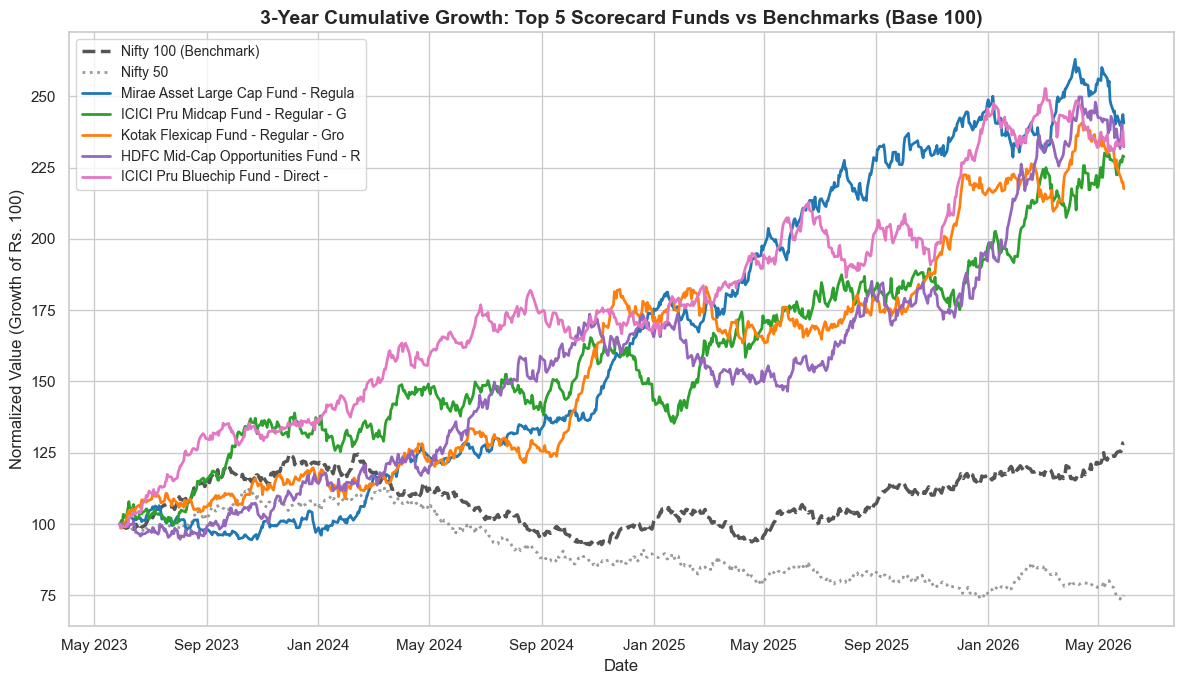

Tracking Error over 3 years:
Mirae Asset Large Cap Fund - Regula      | TE vs Nifty 50: 19.19% | TE vs Nifty 100: 18.80%
ICICI Pru Midcap Fund - Regular - G      | TE vs Nifty 50: 22.84% | TE vs Nifty 100: 23.27%
Kotak Flexicap Fund - Regular - Gro      | TE vs Nifty 50: 20.51% | TE vs Nifty 100: 20.65%
HDFC Mid-Cap Opportunities Fund - R      | TE vs Nifty 50: 22.82% | TE vs Nifty 100: 22.50%
ICICI Pru Bluechip Fund - Direct -       | TE vs Nifty 50: 18.82% | TE vs Nifty 100: 18.73%


In [10]:
top_5_amfi = scorecard["amfi_code"].head(5).tolist()
available_dates = df_aligned["date"].unique()
start_date = available_dates[np.abs(available_dates - np.datetime64("2023-05-29")).argmin()]
end_date = df_aligned["date"].max()

df_3yr_analysis = df_aligned[(df_aligned["date"] >= start_date) & (df_aligned["date"] <= end_date)].copy()

# Plotting
plt.figure(figsize=(12, 7))

# Normalize Benchmarks to 100
df_bench_3yr = df_benchmarks[(df_benchmarks["date"] >= start_date) & (df_benchmarks["date"] <= end_date)].sort_values("date").copy()
n50_start = df_bench_3yr["nifty50_close"].iloc[0]
n100_start = df_bench_3yr["nifty100_close"].iloc[0]

plt.plot(df_bench_3yr["date"], 100.0 * df_bench_3yr["nifty100_close"] / n100_start, label="Nifty 100 (Benchmark)", color="#555555", linewidth=2.5, linestyle="--")
plt.plot(df_bench_3yr["date"], 100.0 * df_bench_3yr["nifty50_close"] / n50_start, label="Nifty 50", color="#999999", linewidth=2.0, linestyle=":")

# Plot top 5 funds
colors = ["#1f77b4", "#2ca02c", "#ff7f0e", "#9467bd", "#e377c2"]
for i, amfi in enumerate(top_5_amfi):
    df_f = df_3yr_analysis[df_3yr_analysis["amfi_code"] == amfi].sort_values("date").copy()
    nav_start_val = df_f["nav"].iloc[0]
    plt.plot(df_f["date"], 100.0 * df_f["nav"] / nav_start_val, label=df_f["scheme_name"].iloc[0][:35], color=colors[i], linewidth=2.0)

plt.title("3-Year Cumulative Growth: Top 5 Scorecard Funds vs Benchmarks (Base 100)", fontsize=14, fontweight="bold")
plt.xlabel("Date", fontsize=12)
plt.ylabel("Normalized Value (Growth of Rs. 100)", fontsize=12)
plt.legend(loc="upper left", fontsize=10)
plt.gca().xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%b %Y"))
plt.tight_layout()
plt.show()

# Tracking Error Calculation
df_3yr_analysis["fund_return"] = df_3yr_analysis.groupby("amfi_code")["nav"].pct_change()
df_3yr_analysis["nifty50_return"] = df_3yr_analysis.groupby("amfi_code")["nifty50_close"].pct_change()
df_3yr_analysis["nifty100_return"] = df_3yr_analysis.groupby("amfi_code")["nifty100_close"].pct_change()
df_3yr_analysis_clean = df_3yr_analysis.dropna(subset=["fund_return"])

print("Tracking Error over 3 years:")
for amfi in top_5_amfi:
    df_f = df_3yr_analysis_clean[df_3yr_analysis_clean["amfi_code"] == amfi]
    name = df_f["scheme_name"].iloc[0]
    te_n50 = np.std(df_f["fund_return"] - df_f["nifty50_return"], ddof=1) * np.sqrt(252)
    te_n100 = np.std(df_f["fund_return"] - df_f["nifty100_return"], ddof=1) * np.sqrt(252)
    print(f"{name[:35]:<40} | TE vs Nifty 50: {te_n50*100:.2f}% | TE vs Nifty 100: {te_n100*100:.2f}%")